In [11]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import numpy as np
import math

import torch
from torch import Tensor, nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from common.const import DATASET_PATH
from common.util import *
from common.ffn_model.minst.ffn_minst_util import MetaData
from common.optimise import OptimiserEtaSoftmaxArmihoNorm2Base, OptimiserEtaSoftmaxArmihoNorm1Base, reduce_to_active

from torchvision.datasets import CIFAR10
from torchvision import transforms

import logging

In [12]:
logging.basicConfig(filename="log_convcrity_cifar10_epochsd.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")
#                datefmt="%m/%d/%Y %I:%M:%S")


#### CIFAR10 dataset

In [13]:
# Convert from PIL to torch.Tensort
# and normalize each pixel from [0, 255] range to [0.0, 1.0]
base_transforms = transforms.ToTensor()

# An augmentation that randomly (with a probability equal to 0.5)
# flips the image horizontally
# This will prevent overfitting and make the model more robust
aug_transforms = transforms.RandomHorizontalFlip(p=0.5)

# Gather all transforms together
train_transforms = transforms.Compose([
    base_transforms,
    aug_transforms
])

train_dataset = CIFAR10(root=DATASET_PATH, train=True, download=True, transform=train_transforms)

# Note that we only use `base_transforms` for test dataset
test_dataset = CIFAR10(root=DATASET_PATH, train=False, download=True, transform=base_transforms)

Files already downloaded and verified
Files already downloaded and verified


In [14]:
BATCH_SIZE = 64 #64 #32

# `pin_memory` speed up processing if you use GPU
# `num_workers` also speed up processing since use additional process
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             num_workers=0, pin_memory=True)

In [15]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM=32*32 #*3 USING 0.299 ∙ Red + 0.587 ∙ Green + 0.114 ∙ Blue for gray-transform
OUTPUT_DIM = 10 #26  # num of classes

lb, lw = 0.005, 5.0
meta = MetaData(input_dim = INPUT_DIM, output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE, lb = 0.005, lw = 5.0, reduction='mean')

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


##### UTILS

#### Compare optimisers

In [16]:
def init_weights_copy(net, params):
    net.init_linear_zeros(net.conv1, True)
    net.init_linear_zeros(net.conv2, True)
    net.init_linear_zeros(net.conv3, True)
    net.init_linear_zeros(net.conv4, True)
    net.init_linear_zeros(net.linear5, True)
    net.init_linear_zeros(net.linear6, True)
    with torch.no_grad():
        net.conv1.weight += torch.from_numpy(params['0.weight']).to(DEVICE)
        net.conv1.bias += torch.from_numpy(params['0.bias']).to(DEVICE)
        net.conv2.weight += torch.from_numpy(params['2.weight']).to(DEVICE)
        net.conv2.bias += torch.from_numpy(params['2.bias']).to(DEVICE)
        net.conv3.weight += torch.from_numpy(params['6.weight']).to(DEVICE)
        net.conv3.bias += torch.from_numpy(params['6.bias']).to(DEVICE)
        net.conv4.weight += torch.from_numpy(params['8.weight']).to(DEVICE)
        net.conv4.bias += torch.from_numpy(params['8.bias']).to(DEVICE)
        net.linear5.weight += torch.from_numpy(params['13.weight']).to(DEVICE)
        net.linear5.bias += torch.from_numpy(params['13.bias']).to(DEVICE)
        net.linear6.weight += torch.from_numpy(params['16.weight']).to(DEVICE)
        net.linear6.bias += torch.from_numpy(params['16.bias']).to(DEVICE)

def print_comparison(HISTORY_NORM1, HISTORY_NORM2, HISTORY_OPTFIX):
    #start_epoch, finish_epoch = 10, 20
    display.clear_output()
    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    axes[0].set_title('Loss (Cross Entropy)')
    #axes[0].set_xlim(start_epoch-1, finish_epoch)
    #axes[0].plot(HISTORY_NORM1['train_loss'][2:40], color='g', ls='dotted', alpha=.5, label='Train norm1')
    #axes[0].plot(HISTORY_NORM2['train_loss'][2:40], color='b', ls='dotted', alpha=.5, label='Train norm2')
    #axes[0].plot(HISTORY_ZHS['train_loss'][2:40], color='r', ls='dotted', alpha=.5, label='Train Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['train_loss'][2:40], color='orange', ls='dotted', alpha=.5, label='Train Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['train_loss'][2:40], color='brown', ls='dotted', alpha=.5, label='Train direct Zhang-lambda')
    axes[0].plot(HISTORY_NORM1['test_loss'], color='g', alpha=.5, label='Test norm1')
    axes[0].plot(HISTORY_NORM2['test_loss'], color='b', alpha=.5, label='Test norm2')
    #axes[0].plot(HISTORY_ZHS['test_loss'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['test_loss'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['test_loss'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[0].plot(HISTORY_OPTFIX['test_loss'], color='grey', alpha=.5, label='Test Nesterov-fix optimiser')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0].set_ylabel("Loss value")

    axes[1].set_title('Accuracy')
    #axes[1].set_xlim(10, 20)
    #axes[1].plot(HISTORY_NORM1['train_accuracy'][2:40], color='g', alpha=.5, ls='dotted', label='Train norm1')
    #axes[1].plot(HISTORY_NORM2['train_accuracy'][2:40], color='b', alpha=.5, ls='dotted', label='Train norm2')
    #axes[1].plot(HISTORY_ZHS['train_accuracy'][2:40], color='r', alpha=.5, ls='dotted', label='Train Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['train_accuracy'][2:40], color='orange', alpha=.5, ls='dotted', label='Train Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['train_accuracy'][2:40], color='brown', alpha=.5, ls='dotted', label='Train direct Zhang-lambda')
    axes[1].plot(HISTORY_NORM1['test_accuracy'], color='g', alpha=.5, label='Test norm1')
    axes[1].plot(HISTORY_NORM2['test_accuracy'], color='b', alpha=.5, label='Test norm2')
    #axes[1].plot(HISTORY_ZHS['test_accuracy'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['test_accuracy'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['test_accuracy'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[1].plot(HISTORY_OPTFIX['test_accuracy'], color='grey', alpha=.5, label='Test Nesterov-fix optimiser')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[1].set_ylabel("Accuracy value")

    #fig.tight_layout()
    #fig.subplots_adjust(top=0.95)
    dummy=fig.suptitle("Comparison for the same FFN-structure for different optimisers")

    plt.show()

#### Reference CNN

In [17]:
def make_model():
    
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25),
        nn.Flatten(),
        nn.Linear(4096, 256),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.5),
        nn.Linear(256, 10)        
    )

    return model

#### Adapted CNN with the same layers

In [18]:
class CIFAR10ReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.slope_positive = None
        self.slope_negative = None
        self.do_dropout = False

        self.kernel_size_=(3, 3)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=self.kernel_size_, padding='same')
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=self.kernel_size_, padding='same')
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=self.kernel_size_, padding='same')
        self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=self.kernel_size_, padding='same')
        self.linear5 = nn.Linear(4096, 256)
        self.linear6 = nn.Linear(256, 10)

    def set_slopes(self, slope_positive = 1.0, slope_negative = 0.25):
        self.slope_positive = slope_positive
        self.slope_negative = slope_negative

    def PReLU(self, input: Tensor) -> Tensor:
        input = torch.where(input >= 0, self.slope_positive * input, self.slope_negative * input)
        return input

    def forward_(self, x):
        return self.forward(x)
    
    def forward(self, x):
        #channels*size*size
        #3*32*32->16*32*32 <padding='same'?>
        h1 = self.PReLU(self.conv1(x))
        #16*32*32->32*32*32->32*16*16 <padding='same'?>
        h2 = F.max_pool2d(self.PReLU(self.conv2(h1)), 2)
        if self.do_dropout:
            h2 = F.dropout(h2, 0.25)
        #32*16*16->32*16*16 <padding='same'?>
        h3 = self.PReLU(self.conv3(h2))
        #32*16*16->64*16*16->64*8*8 <padding='same'?>
        h4 = F.max_pool2d(self.PReLU(self.conv4(h3)), 2)
        if self.do_dropout:
            h4 = F.dropout(h4, 0.25)
        #64*8*8->4096->256
        h4flat = torch.flatten(h4, 1)
        h5 = self.PReLU(self.linear5(h4flat))
        if self.do_dropout:
            h5 = F.dropout(h5, 0.5)
        return self.linear6(h5)
    
    def init_weights(self, cb=0.0, cw=1.0):
        logging.debug("CNN weights initialisation with cb={}, cw={}".format(cb, cw))

        #Weight initialisation as in 2.19, 2.20
        self.cb, self.cw = cb, cw
        kernel_size = self.kernel_size_[0]*self.kernel_size_[1]
        self.init_linear_weights(self.conv1, True, cb, cw/kernel_size)
        self.init_linear_weights(self.conv2, True, cb, cw/kernel_size)
        self.init_linear_weights(self.conv3, True, cb, cw/kernel_size)
        self.init_linear_weights(self.conv4, True, cb, cw/kernel_size)
        self.init_linear_weights(self.linear5, True, cb, cw/self.linear5.in_features)
        self.init_linear_weights(self.linear6, True, cb, cw/self.linear6.in_features)

    @staticmethod
    def init_linear_weights(linear, bias_on, var_b=0.0, var_w=1.0):
        nn.init.normal_(linear.weight, mean = 0., std = math.sqrt(var_w)) #approach via torch
        if bias_on:
            nn.init.normal_(linear.bias, mean = 0., std = math.sqrt(var_b))

    @staticmethod
    def init_linear_zeros(linear, bias_on):
        nn.init.zeros_(linear.weight)
        if bias_on:
            nn.init.zeros_(linear.bias)

In [19]:
HISTORY_NORM1 = collections.defaultdict(list)
HISTORY_NORM2 = collections.defaultdict(list)
HISTORY_OPTFIX = collections.defaultdict(list)

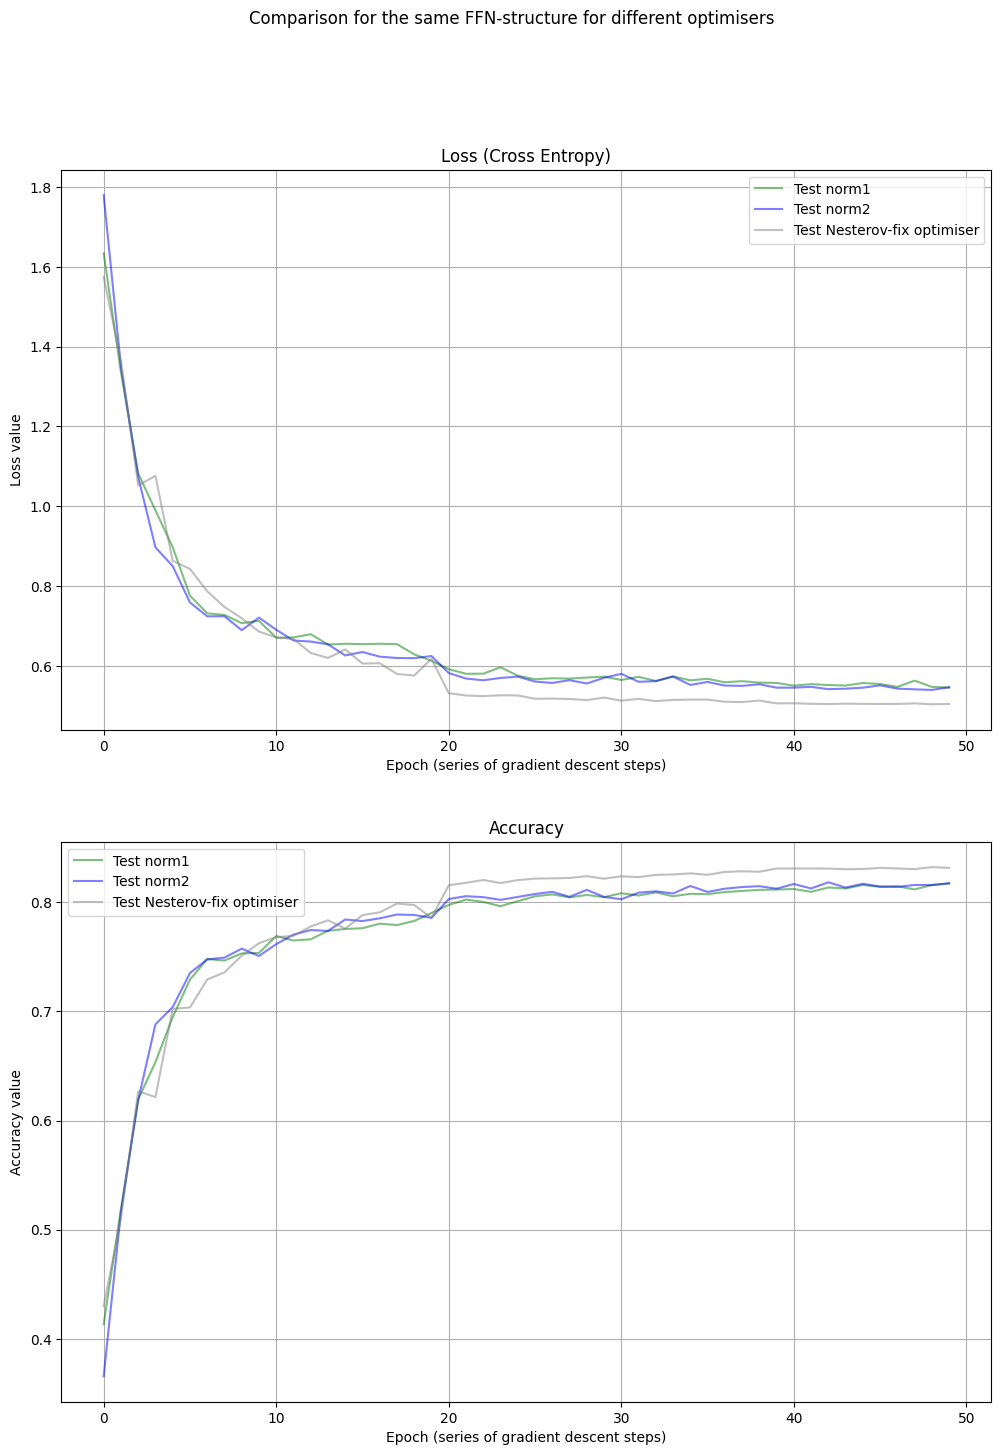

accuracy:
norm1=[0.4133160828025478, 0.5189092356687898, 0.619327229299363, 0.653562898089172, 0.694765127388535, 0.7291003184713376, 0.7480095541401274, 0.7466162420382165, 0.7531847133757962, 0.7535828025477707, 0.7691082802547771, 0.7650278662420382, 0.7661226114649682, 0.7738853503184714, 0.775577229299363, 0.7762738853503185, 0.7804538216560509, 0.7791600318471338, 0.7829418789808917, 0.7902070063694268, 0.7975716560509554, 0.802547770700637, 0.8003582802547771, 0.7964769108280255, 0.8010549363057324, 0.8055334394904459, 0.8072253184713376, 0.8045382165605095, 0.8067277070063694, 0.8047372611464968, 0.8083200636942676, 0.8062300955414012, 0.8091162420382165, 0.8055334394904459, 0.8078224522292994, 0.8074243630573248, 0.8094148089171974, 0.8104100318471338, 0.81140525477707, 0.8117038216560509, 0.8122014331210191, 0.8096138535031847, 0.81359474522293, 0.8126990445859873, 0.8158837579617835, 0.8140923566878981, 0.8147890127388535, 0.8118033439490446, 0.8158837579617835, 0.8171775477

In [ ]:
def test_loop(testNet, test_loss_meter, test_accuracy_meter):
    for test_batch in test_dataloader:
        images, labels = test_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            logits = testNet.forward(images)

            zz_logits = np.transpose(logits.detach().cpu().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

NUM_EPOCH = 50
eta_fixed = 0.01

testOptfix = make_model().to(DEVICE)
loss_fnFix = nn.CrossEntropyLoss()
optimizerFix = optim.SGD(testOptfix.parameters(), lr=eta_fixed, momentum=0.9, nesterov=True)
params = {k: v.detach().cpu().numpy().copy() for k, v in testOptfix.named_parameters()}

stepCalcSoftmax2 = OptimiserEtaSoftmaxArmihoNorm2Base(meta, DEVICE)
testNorm2S = CIFAR10ReLU()
testNorm2S.set_slopes(slope_plus, slope_minus)
testNorm2S.do_dropout = False
testNorm2S.to(DEVICE)
init_weights_copy(testNorm2S, params)

stepCalcSoftmax1 = OptimiserEtaSoftmaxArmihoNorm1Base(meta, DEVICE)
testNorm1S = CIFAR10ReLU()
testNorm1S.set_slopes(slope_plus, slope_minus)
testNorm1S.do_dropout = False
testNorm1S.to(DEVICE)
init_weights_copy(testNorm1S, params)

#qu = collections.deque(10*[1.0], 10)
use_ones=False
for epoch in range(NUM_EPOCH): #eta_fixed if epoch < 5 else eta_fixed * 0.1 if epoch < 10 else eta_fixed * 0.01
    do_dropout = not(epoch < 5)
    use_fix = False #do_dropout
    use_ones= (epoch < 1) #not(epoch < 1) # #

    #eta_min = 0.01 if epoch < 1 else 0.00001
    eta_min = eta_fixed if epoch < 20 else eta_fixed * 0.1 if epoch < 40 else eta_fixed * 0.01
    eta_max = 1 if epoch < 1 else 0.05 if epoch < 20 else 0.005
    c1 = 0.001 #if epoch < 1 else 0.01 if epoch < 5 else 0.0125 if epoch < 15 else 0.015
    c2 = 0.999 if epoch < 1 else 0.75 if not do_dropout else 0.925 if epoch < 20 else 0.9999

    stepCalcSoftmax1.eta_min = eta_min
    stepCalcSoftmax1.eta_max = eta_max
    stepCalcSoftmax1.stepProcessor.c1 = c1
    stepCalcSoftmax1.stepProcessor.c2 = c2
    testNorm1S.do_dropout = do_dropout

    stepCalcSoftmax2.eta_min = eta_min
    stepCalcSoftmax2.eta_max = eta_max
    stepCalcSoftmax2.stepProcessor.c1 = c1
    stepCalcSoftmax2.stepProcessor.c2 = c2
    testNorm2S.do_dropout = do_dropout
    '''
    c1 = 0.001 if epoch < 1 else 0.01 if epoch < 5 else 0.0125 if epoch < 15 else 0.015 #if epoch < 20 else 0.0175
    c2 = 0.999 if epoch < 1 else 0.75 if epoch < 5 else 0.925  if epoch < 15 else 0.9999
    stepCalcSoftmax2.stepProcessor.c1 = 0.001 if epoch < 1 else 0.01 if epoch < 5 else 0.0125 if epoch < 20 else 0.015
    stepCalcSoftmax2.stepProcessor.c2 = 0.999 if epoch < 1 else 0.75 if epoch < 5 else 0.925   if epoch < 20 else 0.9999
    stepCalcSoftmax2.stepProcessor.c1 = 0.001 if epoch < 1 else 0.01 if epoch < 5 else 0.0125 if epoch < 20 else 0.015
    stepCalcSoftmax2.stepProcessor.c2 = 0.999 if epoch < 1 else 0.75 if epoch < 5 else 0.925  if epoch < 20 else 0.9999    
    "    stepCalcSoftmax2.stepProcessor.c1 = 0.001 if epoch < 1 else 0.01 if epoch < 5 else 0.0125\n",
    "    stepCalcSoftmax2.stepProcessor.c2 = 0.999 if epoch < 1 else 0.75 if epoch < 5 else 0.95\n",    
    '''
         #0.80 if epoch <= 15 else 0.85 if epoch <= 25 else 0.90
    #stepCalcSoftmax2.c1 = 0.001 if epoch < 10 else 0.01 if epoch < 15 else 0.013
        #eta_fixed * math.exp(-0.075*epoch) if epoch < 20 else eta_fixed * 0.1 * math.exp(-0.075*(epoch-20))
     #!-0.075 -0.085 ?0.185 !?-0.175 !-0.15 !-0.115
    #if epoch < 20 else eta_fixed * 0.1 * math.exp(-0.1*(epoch-20))
    optimizerFix.param_groups[0]['lr'] = \
        eta_fixed if epoch < 20 else eta_fixed * 0.1 if epoch < 40 else eta_fixed * 0.01
    '''
    if len(HISTORY_NORM2['test_loss'])> 2 and do_dropout == False \
        and HISTORY_NORM2['test_loss'][-1] >= HISTORY_NORM2['test_loss'][-2]:
        logging.info("##For norm2-optim-simple do_dropout switched to True")
        do_dropout == True
    '''
    testOptfix.train()
    iter=0
    train_eta2_meter, train_armiho2_meter, train_wolf2_meter = AverageMeter(), AverageMeter(), AverageMeter()
    train_eta1_meter, train_armiho1_meter, train_wolf1_meter = AverageMeter(), AverageMeter(), AverageMeter()

    for train_batch in train_dataloader:
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        pp = labels_to_softhot(labels, meta.output_dim)
        iter+=1

        logging.info("##Step with norm2-optim-simple")
        logging.info("##\n --==Epoch={}, iter={}; momentum={}, Nesterov={}, eta_min={}==--"\
                     .format(epoch, iter, 0.9, True, stepCalcSoftmax2.eta_min))
        with torch.no_grad():
            logits = testNorm2S.forward_(images)
            logits_detached = logits.detach().cpu().numpy()
            qq = softmax(np.transpose(logits_detached), axis=(0)) + 1e-8
            qq_active = reduce_to_active(qq, pp)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}==--"\
                        .format(np.min(qq_active), np.max(qq_active), np.average(qq_active)))
        step_result = stepCalcSoftmax2\
            .step(testNorm2S, labels, images, momentum=0.9, Nesterov=True, use_ones=use_ones, use_fix=use_fix)
        train_eta2_meter.update(step_result.eta_value)
        train_armiho2_meter.update(step_result.ck_armiho)
        train_wolf2_meter.update(step_result.ck_wolf)

        logging.info("##Step with norm1-optim-simple")
        logging.info("##\n --==Epoch={}, iter={}; momentum={}, Nesterov={}, eta_min={}==--"\
                     .format(epoch, iter, 0.9, True, stepCalcSoftmax1.eta_min))
        with torch.no_grad():
            logits1 = testNorm1S.forward_(images)
            logits1_detached = logits1.detach().cpu().numpy()
            qq1 = softmax(np.transpose(logits1_detached), axis=(0)) + 1e-8
            qq1_active = reduce_to_active(qq1, pp)
        logging.info("##\n --==Initial qq for ones: min={}, max={}, avg={}==--"\
                        .format(np.min(qq1_active), np.max(qq1_active), np.average(qq1_active)))
        step1_result = stepCalcSoftmax1\
            .step(testNorm1S, labels, images, momentum=0.9, Nesterov=True, use_ones=use_ones, use_fix=use_fix)
        train_eta1_meter.update(step1_result.eta_value)
        train_armiho1_meter.update(step1_result.ck_armiho)
        train_wolf1_meter.update(step1_result.ck_wolf)

        logging.info("##Step with Optim-fix, eta={}".format(optimizerFix.param_groups[0]['lr']))
        logitsOptfix = testOptfix.forward(images)
        lossOptfix = loss_fnFix(logitsOptfix, labels)
        optimizerFix.zero_grad()
        lossOptfix.backward()
        optimizerFix.step()

    HISTORY_NORM1['train_eta'].append(train_eta1_meter.avg)
    HISTORY_NORM1['train_armiho'].append(train_armiho1_meter.avg)
    HISTORY_NORM1['train_wolf'].append(train_wolf1_meter.avg)

    HISTORY_NORM2['train_eta'].append(train_eta2_meter.avg)
    HISTORY_NORM2['train_armiho'].append(train_armiho2_meter.avg)
    HISTORY_NORM2['train_wolf'].append(train_wolf2_meter.avg)

    testNorm1S.do_dropout = False
    testNorm2S.do_dropout = False
    testOptfix.eval()
    # testing loop
    test_loss1S_meter, test_accuracy1S_meter = AverageMeter(), AverageMeter(),
    test_loop(testNorm1S, test_loss1S_meter, test_accuracy1S_meter)
    HISTORY_NORM1['test_loss'].append(test_loss1S_meter.avg)
    HISTORY_NORM1['test_accuracy'].append(test_accuracy1S_meter.avg)

    test_loss2S_meter, test_accuracy2S_meter = AverageMeter(), AverageMeter(),
    test_loop(testNorm2S, test_loss2S_meter, test_accuracy2S_meter)
    HISTORY_NORM2['test_loss'].append(test_loss2S_meter.avg)
    HISTORY_NORM2['test_accuracy'].append(test_accuracy2S_meter.avg) 

    test_lossOptfix_meter, test_accuracyOptfix_meter = AverageMeter(), AverageMeter(),
    test_loop(testOptfix, test_lossOptfix_meter, test_accuracyOptfix_meter)
    HISTORY_OPTFIX['test_loss'].append(test_lossOptfix_meter.avg)
    HISTORY_OPTFIX['test_accuracy'].append(test_accuracyOptfix_meter.avg)
    
    print_comparison(HISTORY_NORM1, HISTORY_NORM2, HISTORY_OPTFIX)
    print("accuracy:\nnorm1={},\nnorm2={}, \naccuracy Nesterov-fix={}"\
          .format(HISTORY_NORM1['test_accuracy'], HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy']))


In [27]:
HISTORY_NORM2['train_armiho']

[0.01303878975512528,
 0.013101354241473856,
 0.01338781455577223,
 0.013646537381101052,
 0.01386243297748749,
 0.014924237056491403,
 0.01494206797633916,
 0.01493130641481285,
 0.014938584589990134,
 0.014938879376996542,
 0.014933395151040953,
 0.014914494528659636,
 0.014928470788375333,
 0.014931981876643415,
 0.014921067999698327,
 0.01491190081324209,
 0.014902573340237722,
 0.014912544037182117,
 0.014892084582097764,
 0.014904960605855394,
 0.015387768634495343,
 0.015377153645528316,
 0.015384489566078241,
 0.015384321497069477,
 0.015380419049280777,
 0.015406967498879116,
 0.015394055612818858,
 0.015396330365986362,
 0.01538685152860752,
 0.015406169552293673,
 0.015412316752634993,
 0.015401714978511706,
 0.015408566292075791,
 0.015412165022051016,
 0.015406988417764098,
 0.015405497426339806,
 0.015419630978824386,
 0.015409606124383924,
 0.015404031565573595,
 0.015411829827370037,
 0.015417399333480596,
 0.015422719366541547,
 0.015424071061528637,
 0.015424683350969

In [28]:
HISTORY_NORM2['train_wolf']

[0.6926040726654193,
 0.6706697198909386,
 0.6764149556836235,
 0.6777642981978756,
 0.6763338218004947,
 0.8960595992951258,
 0.8961742400477524,
 0.894993736297919,
 0.8943699097120007,
 0.8956969338097869,
 0.8959635662126781,
 0.8948248555633018,
 0.8945665328169137,
 0.89585602673575,
 0.8964013957112498,
 0.8953899219886319,
 0.8959196729769701,
 0.8958531212368727,
 0.8945069657001957,
 0.8940762862262204,
 0.9655384595385776,
 0.964279092235265,
 0.9650164366260161,
 0.9649068510609967,
 0.9643404716179487,
 0.9671084244576692,
 0.9657149625231283,
 0.966026986975796,
 0.9648317836626306,
 0.9670527257196622,
 0.9674347435265284,
 0.9664137778202899,
 0.9670614280000948,
 0.9675090636044369,
 0.966775257784894,
 0.9666183333727578,
 0.9682032317196775,
 0.9671020160017088,
 0.966470205190066,
 0.9672103196120916,
 0.9676290818719991,
 0.9681580908066505,
 0.9685346638009473,
 0.96848012061746,
 0.9681195269907644,
 0.9679812925790082,
 0.9686179004889799,
 0.9676291253861864,
 

In [29]:
HISTORY_NORM2['train_eta']

[0.023279051688403548,
 0.014797930520192938,
 0.027446742625723566,
 0.026517225587170446,
 0.023556169772822617,
 0.008273429827787598,
 0.0077239223466453585,
 0.007270341905876497,
 0.00718909507077201,
 0.00704037775181084,
 0.006793172310212601,
 0.006885891356955002,
 0.006901975287559372,
 0.006649855573979261,
 0.006524239179078439,
 0.006283046736965637,
 0.006406409149580648,
 0.006205010775155303,
 0.006423081969609504,
 0.006372470696816484,
 0.0019284493873214252,
 0.0019171639441652169,
 0.001874617360233476,
 0.0018501743019597376,
 0.0018441720740058488,
 0.001724679343817259,
 0.0017325694275456371,
 0.0016955906075728116,
 0.0017035549620466512,
 0.0016643955677164554,
 0.0016188943246653578,
 0.0016511928076575317,
 0.001613451090370931,
 0.0016013545566482055,
 0.0015740666073701028,
 0.001547885122168104,
 0.0015519559936263928,
 0.0015628690296146798,
 0.0015625342893584092,
 0.001532733675760098,
 0.0015303280270334639,
 0.0014718808029800723,
 0.001471865417558

In [24]:
print("accuracy norm2={}, \naccuracy Nesterov-fix={}"\
        .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy']))

accuracy norm2=[0.3656449044585987, 0.5165207006369427, 0.6187300955414012, 0.6881966560509554, 0.7039211783439491, 0.7351711783439491, 0.7477109872611465, 0.7493033439490446, 0.7575636942675159, 0.7507961783439491, 0.7616441082802548, 0.7704020700636943, 0.7745820063694268, 0.7737858280254777, 0.7842356687898089, 0.7828423566878981, 0.7853304140127388, 0.7888136942675159, 0.7884156050955414, 0.7857285031847133, 0.8030453821656051, 0.8056329617834395, 0.8047372611464968, 0.8022492038216561, 0.8049363057324841, 0.8076234076433121, 0.8096138535031847, 0.8050358280254777, 0.81140525477707, 0.8049363057324841, 0.8028463375796179, 0.8088176751592356, 0.8101114649681529, 0.8081210191082803, 0.8149880573248408, 0.8095143312101911, 0.8125, 0.8139928343949044, 0.8147890127388535, 0.8125, 0.8167794585987261, 0.8126990445859873, 0.8183718152866242, 0.8134952229299363, 0.8169785031847133, 0.8144904458598726, 0.8140923566878981, 0.8158837579617835, 0.8157842356687898, 0.8175756369426752], 
accuracy

In [25]:
#HISTORY_NORM2['train_eta']
base = []
for epoch in range(10):
    base.append(eta_fixed) #* math.exp(-0.075*epoch) if epoch < 20 else eta_fixed * 0.1 * math.exp(-0.075*(epoch-20)))
np.asarray(HISTORY_NORM2['train_eta'])/np.asarray(base[0:38])
        

ValueError: operands could not be broadcast together with shapes (50,) (10,) 

In [14]:
HISTORY_NORM2['train_eta']

[0.014665529594795479,
 0.015440169184124122,
 0.016600266796751653,
 0.014722933909801093,
 0.012743961948727824,
 0.008527827293491197,
 0.008067047301704702,
 0.008491434631572373,
 0.008168603729333417,
 0.00802781607168327,
 0.007744751881013732,
 0.008013172180362122,
 0.008047069897901967,
 0.008055777113984627,
 0.007906982691922793,
 0.008208794025675705,
 0.008039118890284212,
 0.007982476610540473,
 0.00764675026778798,
 0.007975960951195411]

In [ ]:
HISTORY_NORM2['train_eta']

[0.013527505134022249,
 0.009277434863285711,
 0.0086070797642504,
 0.007985162187594035,
 0.007408182206817095,
 0.0068728927879095755,
 0.006376281516217819,
 0.005915886047137713,
 0.005488863030226298,
 0.0050946015422383036,
 0.004733813318898004,
 0.004392553897358442,
 0.004084760229643128,
 0.003802145267919253,
 0.003557414481612458,
 0.003318384061673349,
 0.0030934619129792712,
 0.002910433806084253,
 0.002754594847485997,
 0.002633615220305129,
 0.0021073081397136053,
 0.002067767349029129,
 0.0019929295644926432,
 0.0020184606533114164,
 0.001983161712651638,
 0.0019687265302203725,
 0.0019240437906109659,
 0.0019659193079068324,
 0.0019383042901715164,
 0.0018669031405471469,
 0.0018762375125915126,
 0.0018800636451614134,
 0.0018896789973937979,
 0.00182804641656338,
 0.0018075817823008733,
 0.0017754402462104022,
 0.001785486739718736,
 0.0018074980987763563,
 0.001767527230945539,
 0.0017606376820712944,
 0.0017279195696054928,
 0.0017417798058429906,
 0.00174980697270